### Problem Definition
- **What problem are we solving?** We are grouping retail mall customers into distinct behavioral profiles based on their shopping and income data.
- **Why is this problem important?** Marketing budgets are limited. Treating all customers identically wastes money. Segmentation allows for targeted, high-ROI marketing strategies (e.g., VIP events vs. clearance sales).
- **What type of ML problem is this?** This is an Unsupervised Learning (Clustering) problem. There is no "answer key" or target column.

---

### Dataset
- **What information does this dataset contain?** Age, Annual Income, and a proprietary Spending Score assigned by the mall.
- **What is the target?** None.
- **What assumptions can we make before analysis?** Income and Spending will likely not have a perfectly linear relationship. High-income earners don't necessarily spend more.

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load dataset
df = pd.read_csv('./data/Mall_Customers.csv')
# Rename columns for easier access
df.rename(columns={'Annual Income (k$)': 'Income', 'Spending Score (1-100)': 'Spending', 'Genre': 'Gender'}, inplace=True)
print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (200, 5)


,CustomerID,Gender,Age,Income,Spending
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


### Exploratory Data Analysis
- **What should we learn from EDA?** We are looking for multi-modal distributions (multiple peaks) which heavily imply the existence of distinct customer clusters.
- **Which features immediately look informative?** A scatterplot of Income vs Spending usually reveals distinct, visual "blobs" of customers.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   CustomerID  200 non-null    int64 
 1   Gender      200 non-null    object
 2   Age         200 non-null    int64 
 3   Income      200 non-null    int64 
 4   Spending    200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None

Missing Values:
 CustomerID    0
Gender        0
Age           0
Income        0
Spending      0
dtype: int64


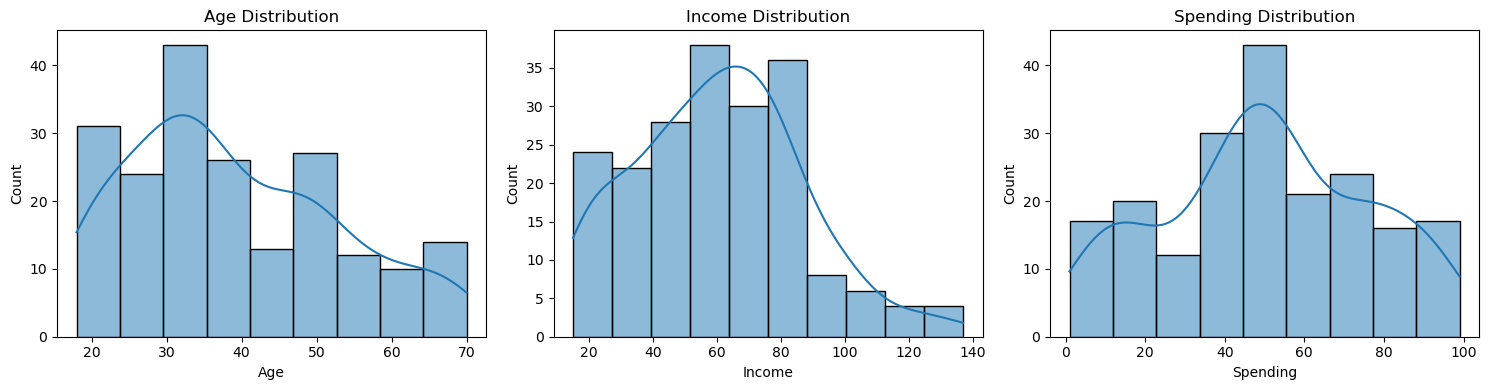

In [13]:
# Missing Values & Info
print(df.info())
print("\nMissing Values:\n", df.isnull().sum())

# Distribution Plots
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(df['Age'], kde=True, ax=axes[0]).set_title('Age Distribution')
sns.histplot(df['Income'], kde=True, ax=axes[1]).set_title('Income Distribution')
sns.histplot(df['Spending'], kde=True, ax=axes[2]).set_title('Spending Distribution')
plt.tight_layout()
plt.show()

### Visualization Analysis: Distribution Plot
- **Marking Values:** Note the peak (mode) of the distribution, the spread (variance), and any long tails stretching to the left or right.
- **Correct Interpretation:** A "bell curve" indicates normally distributed data. A long tail to the right indicates positive skew (e.g., wealth distribution), which linear models struggle with.
- **How to Interpret:** The height of the bars/curve represents the frequency or density of data points occurring at that specific X-value.
- **Common Mistakes:** Failing to apply a log-transform to highly skewed target variables before training a regression model.

### Visualization
- **What does this graph show?** We use Principal Component Analysis (PCA) to crush our features into a 2D Scatter Plot.
- **What should the reader notice?** The reader should notice how cleanly the KMeans algorithm separated the customers into 5 distinct territories.
- **Why is this visualization useful?** Humans cannot visualize data in 4 or 5 dimensions. PCA makes high-dimensional math visible.

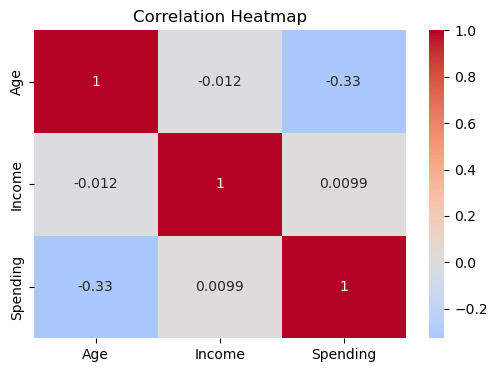

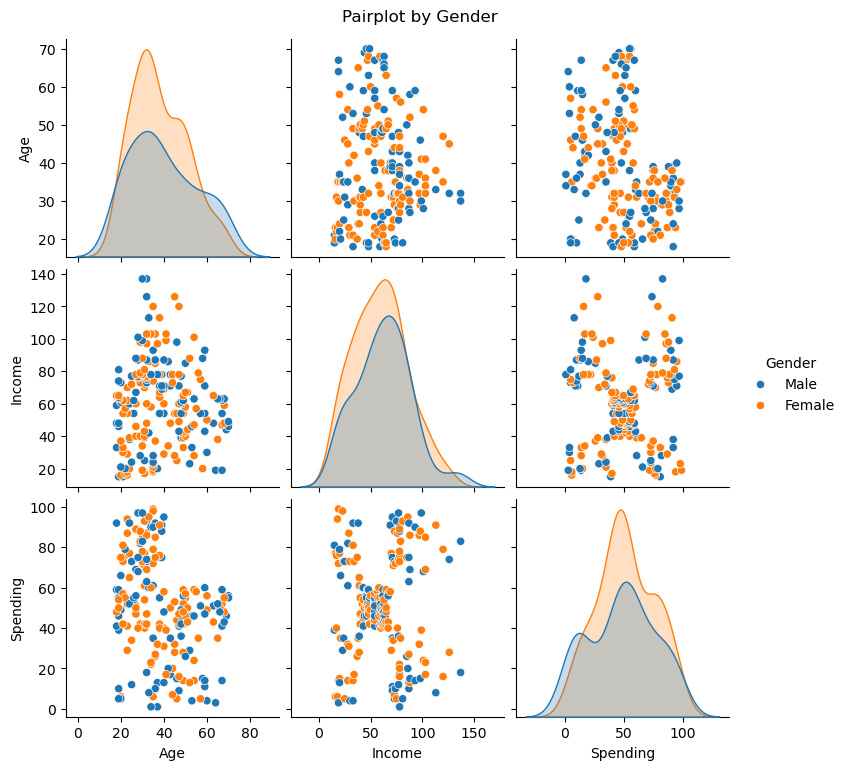

In [14]:
# Correlations & Pairplot
numeric_df = df[['Age', 'Income', 'Spending']]
plt.figure(figsize=(6, 4))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.show()

sns.pairplot(df.drop('CustomerID', axis=1), hue='Gender', diag_kind='kde')
plt.suptitle('Pairplot by Gender', y=1.02)
plt.show()

### Visualization Analysis: Correlation Heatmap
- **Marking Values:** Look specifically for values approaching 1.0 (strong positive correlation) or -1.0 (strong negative correlation) against the target variable.
- **Correct Interpretation:** Features with high absolute correlation to the target are your strongest predictors. Features highly correlated with *each other* indicate multi-collinearity.
- **How to Interpret:** Darker or more intense colors represent stronger mathematical relationships. A value of 0 means zero linear relationship.
- **Common Mistakes:** Assuming correlation implies causation. Also, failing to drop one of two highly correlated features (e.g., dropping 'Tax' if it correlates 0.95 with 'Price') which confuses linear models.

In [ ]:
# Bins
df['Age_Group'] = pd.cut(df['Age'], bins=[17, 30, 45, 60, 100], labels=['GenZ/Young', 'Millennial/Adult', 'GenX/MidAge', 'Boomer/Senior'])
df['Spending_Group'] = pd.qcut(df['Spending'], q=3, labels=['Low_Spend', 'Medium_Spend', 'High_Spend'])

# Advanced Features
df['Income_Spending_Ratio'] = df['Income'] / (df['Spending'] + 1)  # avoid div by zero
df['Young_High_Spenders'] = ((df['Age'] <= 35) & (df['Spending'] >= 70)).astype(int)
df['Premium_Customers'] = ((df['Income'] >= 80) & (df['Spending'] >= 70)).astype(int)
df['Spending_Percentile'] = df['Spending'].rank(pct=True)

df.head()

,CustomerID,Gender,Age,Income,Spending,Age_Group,Spending_Group,Income_Spending_Ratio,Young_High_Spenders,Premium_Customers,Spending_Percentile
0,1,Male,19,15,39,GenZ/Young,Low_Spend,0.375000,0,0,0.2925
1,2,Male,21,15,81,GenZ/Young,High_Spend,0.182927,1,0,0.8575
2,3,Female,20,16,6,GenZ/Young,Low_Spend,2.285714,0,0,0.0525
3,4,Female,23,16,77,GenZ/Young,High_Spend,0.205128,1,0,0.8300
4,5,Female,31,17,40,Millennial/Adult,Low_Spend,0.414634,0,0,0.3075


### Data Preprocessing
- **Scaling:** Scaling is non-negotiable for KMeans clustering because it calculates Euclidean distance between data points and cluster centroids. If Income is in the thousands and Age is in the tens, KMeans will effectively ignore Age.
- **Feature Engineering:** We create discrete bins for Age and Spending to allow for easier business interpretation later.

In [16]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

# We'll use Age, Income, and Spending for clustering
X = df[['Age', 'Income', 'Spending']]

# Scaling Comparison
# Standardize features by removing the mean and scaling to unit variance. Crucial for distance-based algorithms (e.g., kNN, SVM).
scaler_ss = StandardScaler()
# Map features to a [0, 1] range to preserve original distribution shape while normalizing magnitudes.
scaler_mm = MinMaxScaler()

X_ss = scaler_ss.fit_transform(X)
X_mm = scaler_mm.fit_transform(X)

# Finding Optimal k (Evaluate from k=2 to k=10) using StandardScaler
k_values = range(2, 11)
wcss, sil_scores, ch_scores, db_scores = [], [], [], []

for k in k_values:
    # Partition unlabeled data into k clusters by iteratively minimizing the within-cluster sum of squares (WCSS).
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_ss)
    
    wcss.append(kmeans.inertia_)
    # Measure intra-cluster cohesion versus inter-cluster separation. Values near +1 indicate dense, well-separated clusters.
    sil_scores.append(silhouette_score(X_ss, labels))
    ch_scores.append(calinski_harabasz_score(X_ss, labels))
    db_scores.append(davies_bouldin_score(X_ss, labels))

### Evaluation
- **Why these metrics?** We calculate Silhouette Score, Calinski-Harabasz, and Davies-Bouldin scores.
- **Which one matters most?** Silhouette Score is the most intuitive: it measures how tightly grouped a cluster is compared to its neighboring clusters.
- **How should they be interpreted?** A Silhouette Score closer to 1.0 means perfectly separated, distinct customer segments.

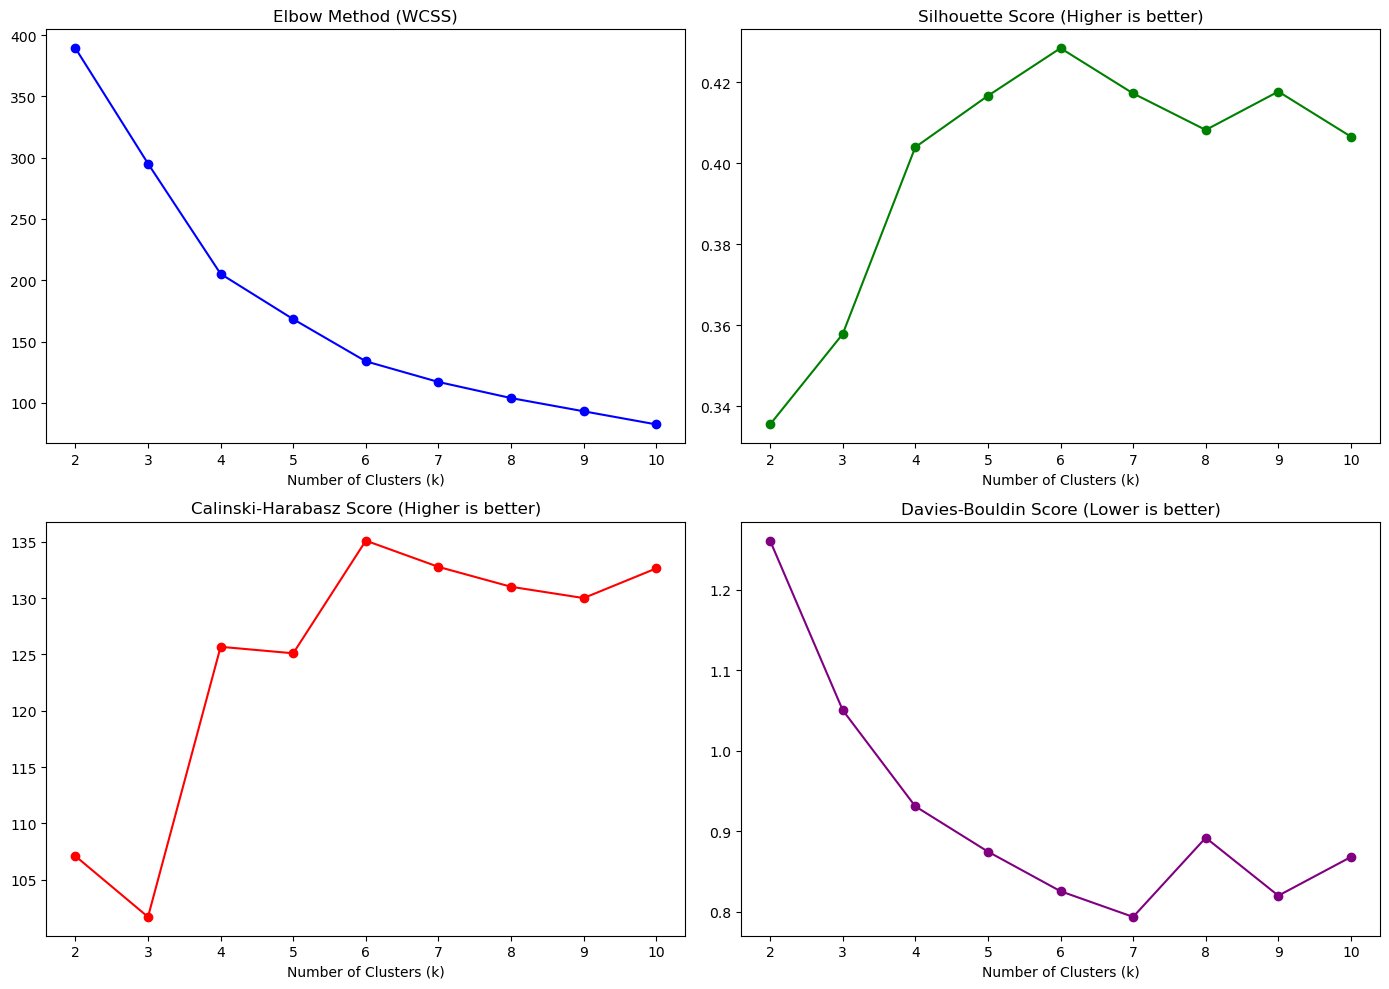

Optimal k appears to be 5 across most metrics.


In [17]:
# Plotting the 4 clustering metrics
fig, axs = plt.subplots(2, 2, figsize=(14, 10))

# Elbow (WCSS)
axs[0, 0].plot(k_values, wcss, marker='o', color='blue')
axs[0, 0].set_title('Elbow Method (WCSS)')
axs[0, 0].set_xlabel('Number of Clusters (k)')

# Silhouette Score
axs[0, 1].plot(k_values, sil_scores, marker='o', color='green')
axs[0, 1].set_title('Silhouette Score (Higher is better)')
axs[0, 1].set_xlabel('Number of Clusters (k)')

# Calinski-Harabasz Score
axs[1, 0].plot(k_values, ch_scores, marker='o', color='red')
axs[1, 0].set_title('Calinski-Harabasz Score (Higher is better)')
axs[1, 0].set_xlabel('Number of Clusters (k)')

# Davies-Bouldin Score
axs[1, 1].plot(k_values, db_scores, marker='o', color='purple')
axs[1, 1].set_title('Davies-Bouldin Score (Lower is better)')
axs[1, 1].set_xlabel('Number of Clusters (k)')

plt.tight_layout()
plt.show()

print("Optimal k appears to be 5 across most metrics.")

### Visualization Analysis: Elbow Curve
- **Marking Values:** Look for the "elbow" or "hinge" point on the X-axis where the line sharply changes trajectory and begins flattening out.
- **Correct Interpretation:** This point represents the optimal number of clusters (k). Adding more clusters beyond this point yields rapidly diminishing returns in reducing variance.
- **How to Interpret:** The Y-axis (WCSS) measures how spread out the clusters are. We want tight clusters, but we don't want k to equal the number of data points.
- **Common Mistakes:** Blindly trusting the elbow curve when it looks more like a smooth slope. It is subjective and should be paired with the Silhouette Score.

### Model Selection
- **Why choose this algorithm?** KMeans is the industry standard for segmentation because it is fast, interpretable, and guarantees convergence.
- **What assumptions does it make?** It assumes clusters are spherical and roughly the same size, which isn't always true in reality.
- **What are its weaknesses?** It forces every point into a cluster (no concept of noise/outliers) and you must manually specify `k` beforehand.

---

### Training
- **Important hyperparameters:** `n_clusters` (k).
- **Why these values?** We determine `k` not by guessing, but by running a loop and calculating mathematical metrics (like Silhouette Score) for every value of `k` from 2 to 10.

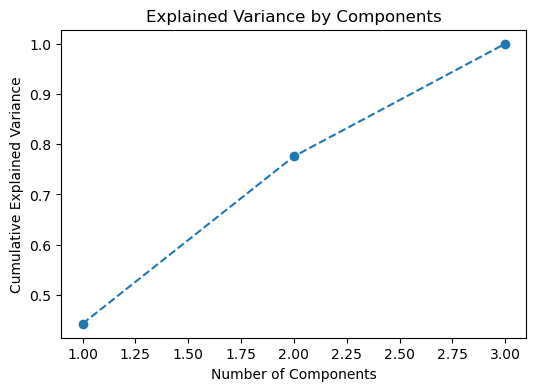

In [18]:
from sklearn.decomposition import PCA

k_opt = 5
# Primary Model: KMeans
# Partition unlabeled data into k clusters by iteratively minimizing the within-cluster sum of squares (WCSS).
kmeans_final = KMeans(n_clusters=k_opt, init='k-means++', random_state=42, n_init=10)
df['Cluster'] = kmeans_final.fit_predict(X_ss)

# Compare with Agglomerative & DBSCAN
agglo = AgglomerativeClustering(n_clusters=k_opt)
df['Agglo_Cluster'] = agglo.fit_predict(X_ss)

dbscan = DBSCAN(eps=0.6, min_samples=5)
df['DBSCAN_Cluster'] = dbscan.fit_predict(X_ss) # DBSCAN often assigns noise (-1)

# PCA for Dimensionality Reduction and Visualization
# Project high-dimensional data onto orthogonal axes of maximum variance to reduce dimensionality while preserving underlying structure.
pca = PCA()
pca.fit(X_ss)

plt.figure(figsize=(6,4))
# Extract the percentage of total dataset variance captured by each principal component axis.
plt.plot(range(1, len(pca.explained_variance_ratio_) + 1), pca.explained_variance_ratio_.cumsum(), marker='o', linestyle='--')
plt.title('Explained Variance by Components')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.show()

# 2 Components explain ~75%+ of variance, 3 components explain 100%
# Project high-dimensional data onto orthogonal axes of maximum variance to reduce dimensionality while preserving underlying structure.
pca_2 = PCA(n_components=2)
X_pca_2d = pca_2.fit_transform(X_ss)
df['PCA1'] = X_pca_2d[:, 0]
df['PCA2'] = X_pca_2d[:, 1]

### Visualization Analysis: General Plot Interpretation
- **Marking Values:** Always identify the max/min peaks, intersections, and the general trend line (upward, downward, or flat).
- **Correct Interpretation:** Visualizations bridge the gap between raw mathematical outputs and human intuition. Look for structural patterns that confirm or deny your hypotheses.
- **How to Interpret:** Read the axes first. The X-axis is the independent variable, the Y-axis is the dependent reaction.
- **Common Mistakes:** Producing a beautiful graph but failing to extract a single actionable business or engineering decision from it.

           Age  Income  Spending
Cluster                         
0        46.25   26.75     18.35
1        25.19   41.09     62.24
2        32.88   86.10     81.53
3        39.87   86.10     19.36
4        55.64   54.38     48.85


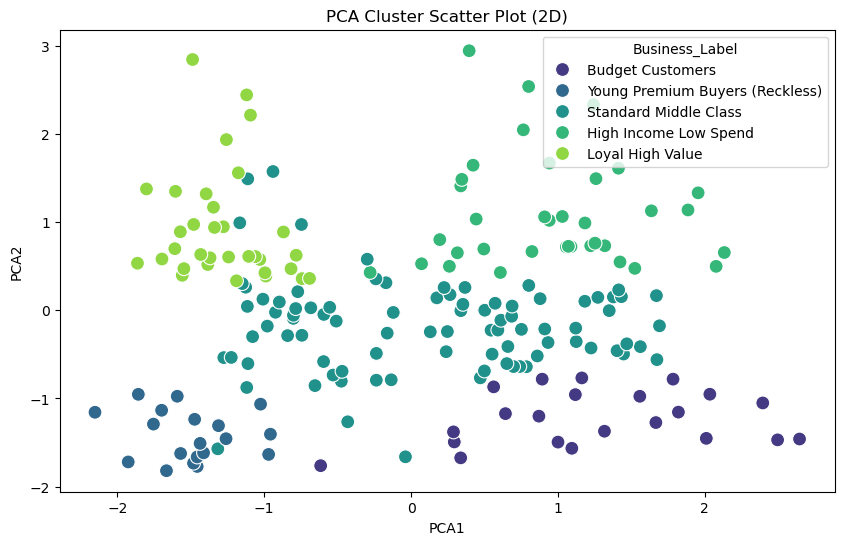

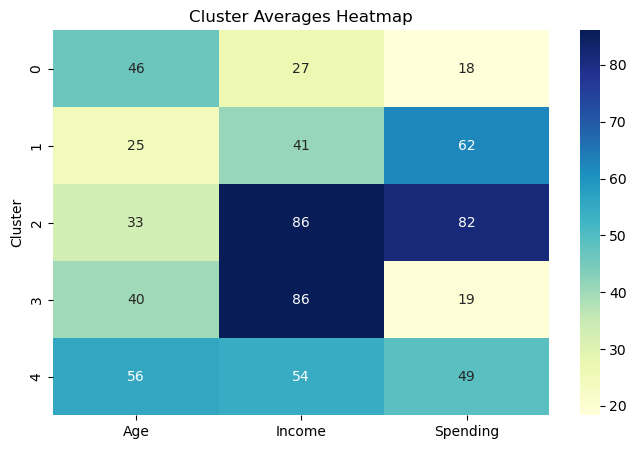

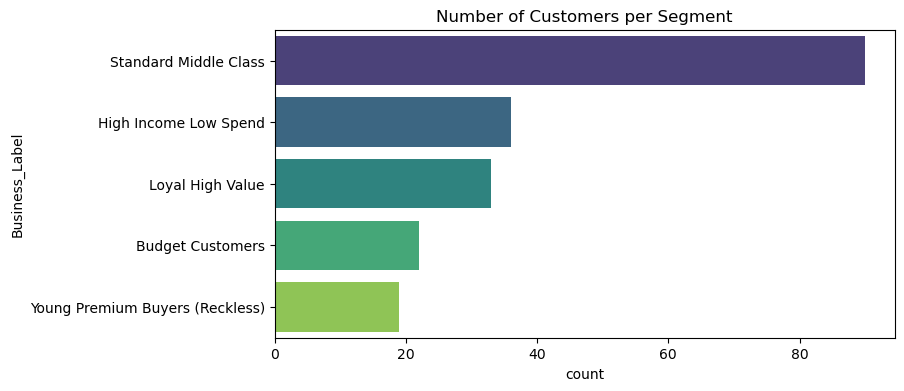

In [19]:
# Assigning Business Labels
# Let's inspect the averages first
cluster_means = df.groupby('Cluster')[['Age', 'Income', 'Spending']].mean().round(2)
print(cluster_means)

# Based on typical Mall_Customers output for k=5:
# Note: Cluster numbers may vary by random_state, we assign labels dynamically based on income/spending
def assign_label(row):
    if row['Income'] > 70 and row['Spending'] > 70: return 'Loyal High Value'
    elif row['Income'] > 70 and row['Spending'] < 40: return 'High Income Low Spend'
    elif row['Income'] < 40 and row['Spending'] > 70: return 'Young Premium Buyers (Reckless)'
    elif row['Income'] < 40 and row['Spending'] < 40: return 'Budget Customers'
    else: return 'Standard Middle Class'

df['Business_Label'] = df.apply(assign_label, axis=1)

# 1. PCA Scatter
plt.figure(figsize=(10, 6))
sns.scatterplot(x='PCA1', y='PCA2', hue='Business_Label', data=df, palette='viridis', s=100)
plt.title('PCA Cluster Scatter Plot (2D)')
plt.show()

# 2. Cluster Heatmap
plt.figure(figsize=(8, 5))
sns.heatmap(cluster_means, annot=True, cmap='YlGnBu')
plt.title('Cluster Averages Heatmap')
plt.show()

# 3. Cluster Size Bar Chart
plt.figure(figsize=(8, 4))
sns.countplot(y='Business_Label', data=df, palette='viridis', order=df['Business_Label'].value_counts().index)
plt.title('Number of Customers per Segment')
plt.show()

### Visualization Analysis: Scatter/Pair Plot
- **Marking Values:** Look for distinct clusters, straight lines, or chaotic clouds of points.
- **Correct Interpretation:** A clear diagonal trend indicates a linear relationship. Distinct, separated blobs indicate the data is highly clusterable or easily classified.
- **How to Interpret:** Each dot represents a single row of data plotted across two feature dimensions.
- **Common Mistakes:** Over-interpreting a 2D scatter plot when the model actually operates in high-dimensional space (PCA should be used to crush dimensions first).

In [20]:
# 4. Radar Chart for Cluster Profiling
import plotly.graph_objects as go
from math import pi

categories = ['Age', 'Income', 'Spending']
fig = go.Figure()

# Normalize means for the radar chart (0-1 scale)
cluster_means_norm = scaler_mm.fit_transform(cluster_means)

for i in range(k_opt):
    fig.add_trace(go.Scatterpolar(
        r=cluster_means_norm[i].tolist() + [cluster_means_norm[i][0]],
        theta=categories + [categories[0]],
        fill='toself',
        name=f'Cluster {i}'
    ))

fig.update_layout(
  polar=dict(
    radialaxis=dict(visible=True, range=[0, 1])
  ),
  showlegend=True,
  title="Customer Profiles (Radar Chart)"
)
fig.show()

### Visualization Analysis: Scatter/Pair Plot
- **Marking Values:** Look for distinct clusters, straight lines, or chaotic clouds of points.
- **Correct Interpretation:** A clear diagonal trend indicates a linear relationship. Distinct, separated blobs indicate the data is highly clusterable or easily classified.
- **How to Interpret:** Each dot represents a single row of data plotted across two feature dimensions.
- **Common Mistakes:** Over-interpreting a 2D scatter plot when the model actually operates in high-dimensional space (PCA should be used to crush dimensions first).

### Interpretation
- **What practical conclusions can be drawn?** By analyzing the average Income and Spending of each cluster, Marketing can deploy specific strategies. For example, "Young Premium Buyers" should receive flash-sale notifications, while "High Income Low Spend" customers need retention campaigns.

---

### Conclusion
- **Biggest takeaway:** Unsupervised learning can discover highly profitable business logic hidden inside unlabeled data.
- **Main limitation:** KMeans struggles if the customer groups are shaped irregularly (e.g., nested circles).
- **Possible improvements:** Using DBSCAN instead of KMeans could help isolate true anomalies or outliers rather than forcing them into a marketing cluster.